In [47]:
import os
from dotenv import find_dotenv, load_dotenv

# This automatically searches upwards for a file named '.env'
load_dotenv(find_dotenv(), override=True)
openai_key = os.getenv("OPENAI_API_KEY")

In [48]:
from langgraph.graph import StateGraph, END
from typing import TypedDict,Annotated
import operator
from langchain_core.messages import AnyMessage,SystemMessage, HumanMessage,ToolMessage
from langchain_openai import ChatOpenAI
#from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.tools.tavily_search import TavilySearchResults
#from langchain_tavily import TavilySearch

In [49]:
tool = TavilySearchResults(max_results=2)
print(type(tool))
print(tool.name)

<class 'langchain_community.tools.tavily_search.tool.TavilySearchResults'>
tavily_search_results_json


In [50]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage],operator.add]

In [51]:
class Agent:
    def __init__(self,model,tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm",self.call_openai)
        graph.add_node("action",self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True:"action",False:END}
        )
        graph.add_edge("action","llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name:t for t in tools}
        self.model = model.bind_tools(tools)


    def exists_action(self,state:AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls)>0

    def call_openai(self,state:AgentState):
        messages = state["messages"]
        if self.system:
            messages = [SystemMessage(content = self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages':[message]}
    
    def take_action(self,state:AgentState):
        tool_calls = state["messages"][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            result = self.tools[t['name']].invoke(t["args"])
            results.append(ToolMessage(tool_call_id = t['id'],name=t["name"],content=str(result)))
        print("Back to the model!")
        return{'messages':results}

In [52]:
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""
model = ChatOpenAI(base_url="https://openrouter.ai/api/v1",model = "gpt-3.5-turbo",api_key=openai_key)
abot = Agent(model,[tool],system=prompt)

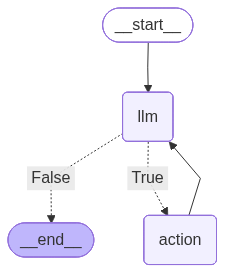

In [53]:
from IPython.display import Image,display
#Image(abot.graph.get_graph().draw_png())
display(Image(abot.graph.get_graph().draw_mermaid_png()))

In [54]:
messages = [HumanMessage(content="What is the weather in sf?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'weather in San Francisco'}, 'id': 'call_Ow1q2Kvxl3JPkXh2jqA2uV7u', 'type': 'tool_call'}
Back to the model!


In [55]:
result['messages'][-1].content


'The weather in San Francisco for May 2026 shows daily high temperatures ranging from 66°F to 73°F, with overnight lows between 53°F and 54°F. The average high for May is 69°F with an average low of 54°F. If you need more specific details or any other information, feel free to ask!'

In [56]:
messages = [HumanMessage(content="What is weather in SF and LA?")]
results = abot.graph.invoke({"messages":messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'weather in San Francisco'}, 'id': 'call_l3aizUNvRC9VLKSNHLok4Z24', 'type': 'tool_call'}
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'weather in Los Angeles'}, 'id': 'call_4yMDgXWD1T883EiN8oiWnaM2', 'type': 'tool_call'}
Back to the model!


In [57]:
results['messages'][-1].content

'The current weather information for San Francisco shows daily high temperatures ranging from 66°F to 73°F and overnight lows between 53°F and 54°F. The average high for May is 69°F with an average low of 54°F. In Los Angeles, the daily high temperatures range from 24.9°C to 27.2°C with overnight lows between 15.4°C and 17.4°C. The average high for May in Los Angeles is 26°C with an average low of 16°C.'

In [58]:
query = "Who won the super bowl in 2024? In what state is the winning team headquarters located? \
What is the GDP of that state? Answer each question." 
messages = [HumanMessage(content=query)]

# model = ChatOpenAI(model="gpt-4o",
#                    base_url="https://openrouter.ai/api/v1",
#                     api_key=openai_key)  # requires more advanced model
# abot = Agent(model, [tool], system=prompt)
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Super Bowl 2024 winner'}, 'id': 'call_Yn9tmG8AY46T1xwsl7ZybiVS', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Kansas City Chiefs headquarters location'}, 'id': 'call_IzBvewn4HEZlvsxpYaLgfsBE', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'GDP of Kansas'}, 'id': 'call_yxFfi0LGjKkzFnXybij4b0h3', 'type': 'tool_call'}
Back to the model!


In [59]:
print(result['messages'][-1].content)

- The Kansas City Chiefs won the Super Bowl in 2024 by defeating the San Francisco 49ers.
- The Kansas City Chiefs' headquarters and training facility are located in Olathe, Johnson County, Kansas.
- The GDP of Kansas was $185.1 billion in 2025.
